In [ ]:
!pip install ultralytics opencv-python

<>:35: SyntaxWarning: invalid escape sequence '\ '
<>:35: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_7169/240026573.py:35: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ -> Detecção: {nome_objeto.upper()} | Confiança: {confianca:.1f}%")


[SISTEMA] Carregar os pesos da Rede Neural (YOLOv8) ...

--- OBJETOS DETECTADOS NO BANCO DE DADOS DA IA ---
 -> detecção: DOG | Confiança: 79.0%
 -> detecção: DOG | Confiança: 69.5%
\ -> Detecção: DOG | Confiança: 69.5%


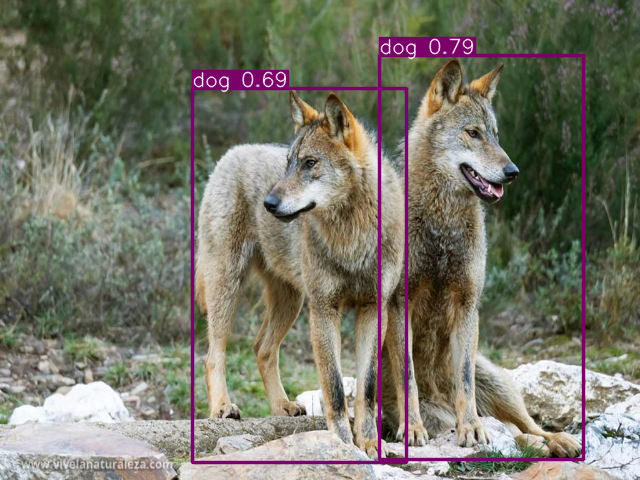

In [ ]:
# DETECÇÃO DE MÚLTIPLOS OBJETOS COM YOLO
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1. Carregar o modelo YOLOv8 pré-treinado
print("[SISTEMA] Carregar os pesos da Rede Neural (YOLOv8) ...")
modelo_yolo = YOLO('yolov8x.pt')

# 2. Ler a imagem estática
imagem_bruta = cv2.imread('nome_imagem.jpg')

# 3. Redimensionar para um tamanho padrão
imagem_redimensionada = cv2.resize(imagem_bruta, (640, 480))

# 4. Limpar a console
resultados = modelo_yolo(imagem_redimensionada, verbose=False)

# 5. Desenhar os retângulos coloridos de forma automática
# e escrever o nome da lcasse (ex: 'person', 'chair')
imagem_final_ia = resultados[0].plot()

print("\n--- OBJETOS DETECTADOS NO BANCO DE DADOS DA IA ---")
for caixa in resultados[0].boxes:
    # Extrair o ID da classe e traduzir para o nome do objeto
    classe_id = int(caixa.cls[0])
    nome_objeto = modelo_yolo.names[classe_id]

    # Extrair o score de confiança
    confianca = float(caixa.conf[0]) * 100

    print(f" -> detecção: {nome_objeto.upper()} | Confiança: {confianca:.1f}%")

# 6. Exibir o painel visual final validação
print(f"\ -> Detecção: {nome_objeto.upper()} | Confiança: {confianca:.1f}%")
cv2_imshow(imagem_final_ia)